In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("cvd_dataset.csv")

In [2]:
#Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0"))

print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_pct
Diastolic BP,82,5.36
Weight (kg),81,5.30
HDL (mg/dL),80,5.23
Waist-to-Height Ratio,79,5.17
Age,78,5.10
Height (cm),74,4.84
Total Cholesterol (mg/dL),73,4.77
Systolic BP,71,4.64
CVD Risk Score,70,4.58
Estimated LDL (mg/dL),69,4.51


Duplicate rows: 0


In [3]:
#strip whitespaces in object columns
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

In [4]:
#summary statistics of numeric variables
display(df[num_cols].describe().T)

#distribution of categorical variables
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts())

NameError: name 'num_cols' is not defined

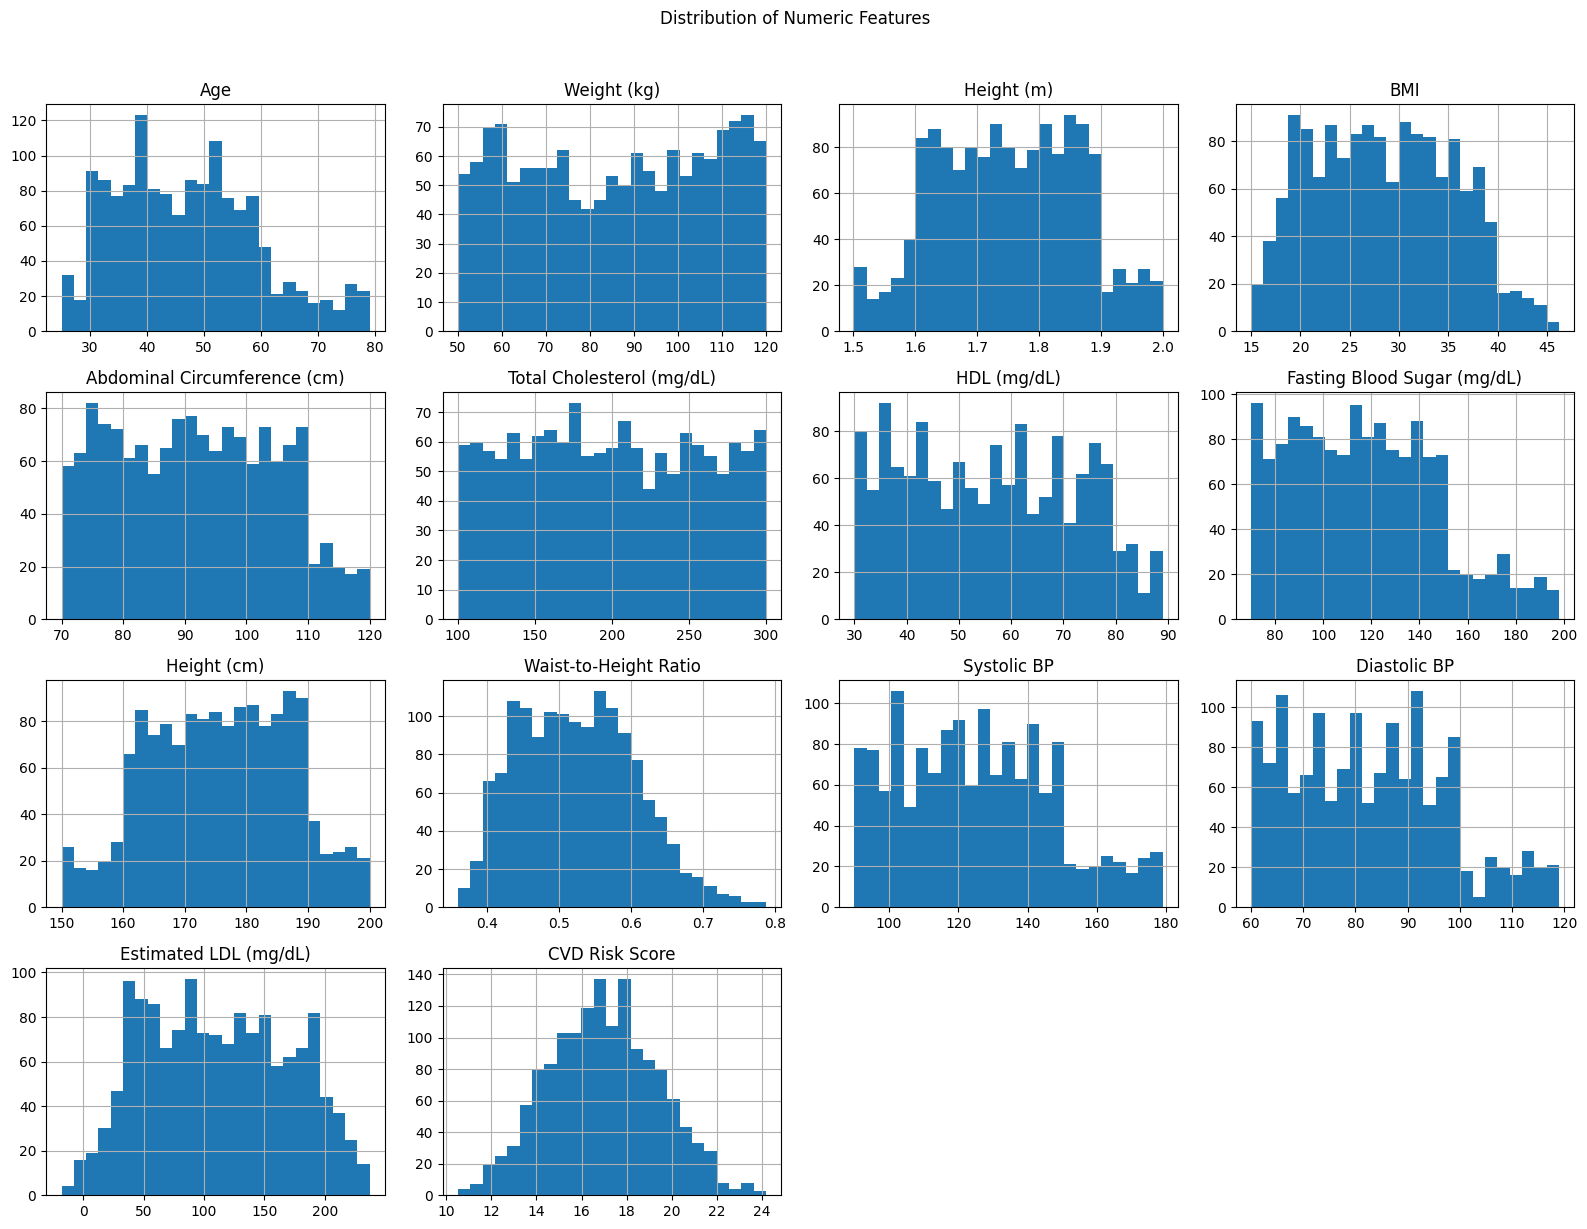

In [13]:
# Histograms for numeric variables
df[num_cols].hist(bins=25, figsize=(16, 12))
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()


CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

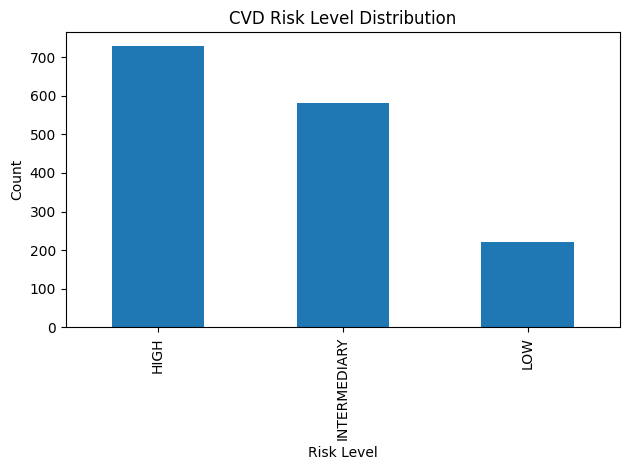

In [6]:
# examining classification balance (high, intermediary, low)
if "CVD Risk Level" in df.columns:
    risk_counts = df["CVD Risk Level"].value_counts()
    display(risk_counts)

    risk_counts.plot(kind="bar")
    plt.title("CVD Risk Level Distribution")
    plt.xlabel("Risk Level")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

CVD Risk Level,HIGH,INTERMEDIARY,LOW
Sex,,,
F,0.490298,0.372574,0.137128
M,0.461640,0.387566,0.150794


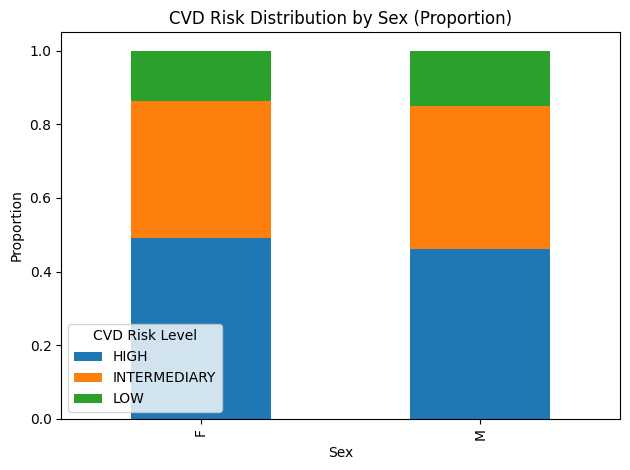

In [10]:
#CVD distribution compared by sex
if "Sex" in df.columns and "CVD Risk Level" in df.columns:
    gender_risk = pd.crosstab(df["Sex"], df["CVD Risk Level"], normalize="index")
    display(gender_risk)

    gender_risk.plot(kind="bar", stacked=True)
    plt.title("CVD Risk Distribution by Sex (Proportion)")
    plt.xlabel("Sex")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns #only select numeric variables
corr_matrix = df[num_cols].corr() 
display(corr_matrix)

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
Age,1.000000,0.018772,0.032374,0.021978,0.074508,0.003215,0.036189,0.104019,0.030656,0.061254,0.092224,0.060314,-0.009122,0.054297
Weight (kg),0.018772,1.000000,0.011726,0.645261,0.043751,0.010221,-0.003709,0.040298,0.012616,0.018778,0.009807,0.002524,0.007230,0.397542
Height (m),0.032374,0.011726,1.000000,-0.164456,0.020897,0.000976,-0.000661,0.021967,0.999999,-0.422906,0.021865,0.012660,0.001518,-0.085316
BMI,0.021978,0.645261,-0.164456,1.000000,0.031422,0.019467,-0.008854,0.039136,-0.174665,0.096286,0.020724,0.023819,0.012521,0.616447
Abdominal Circumference (cm),0.074508,0.043751,0.020897,0.031422,1.000000,0.063085,-0.001065,0.029641,0.018561,0.902775,0.073420,0.040908,0.050242,0.086472
Total Cholesterol (mg/dL),0.003215,0.010221,0.000976,0.019467,0.063085,1.000000,0.058685,0.010712,0.003292,0.048410,0.043958,0.054043,0.962567,0.509151
HDL (mg/dL),0.036189,-0.003709,-0.000661,-0.008854,-0.001065,0.058685,1.000000,0.062371,0.007730,0.014840,0.076026,0.035542,-0.206197,0.047179
Fasting Blood Sugar (mg/dL),0.104019,0.040298,0.021967,0.039136,0.029641,0.010712,0.062371,1.000000,0.021294,0.032002,0.084079,0.086381,0.004133,0.076589
Height (cm),0.030656,0.012616,0.999999,-0.174665,0.018561,0.003292,0.007730,0.021294,1.000000,-0.418214,0.026961,0.015362,0.003689,-0.088247
Waist-to-Height Ratio,0.061254,0.018778,-0.422906,0.096286,0.902775,0.048410,0.014840,0.032002,-0.418214,1.000000,0.067700,0.038665,0.035348,0.115090


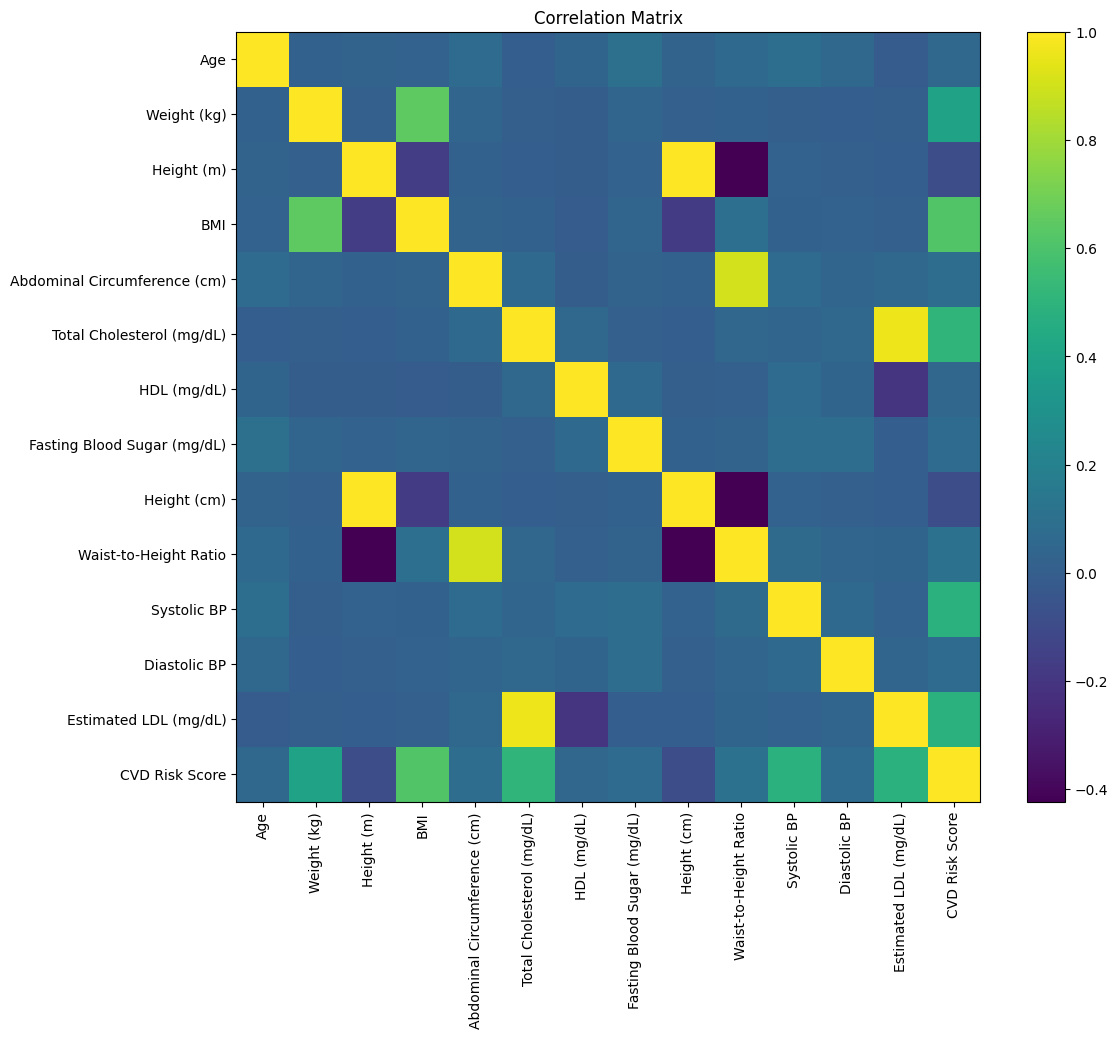

In [6]:
#correlation matrix visualization using heatmap
plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()